**In Python, everything — and I mean everything — is an object.  ----     Because every object is an identity, has type and a value.**

In [8]:
# These are objects
print(type(42))
print(type("hello"))
print(type(type))
print(type(None))

# Functions are object too
def greet(name):
  return f"Hello,{name}"
print(type(greet))

# Fucntions can be assigned to variables
my_func = greet
print(my_func("Saad"))

# Functions can be put in lists
funcs = [my_func, str.upper]
print(funcs[1]("hello"))

# This is object cause it has id, type and value.
x = [1,2,3]
print(id(x))
print(type(x))

<class 'int'>
<class 'str'>
<class 'type'>
<class 'NoneType'>
<class 'function'>
Hello,Saad
HELLO
136117690899584
<class 'list'>


In [9]:
"""This is the #1 source of bugs for beginners. When you do y = x , you DON'T get a copy. You get
                       another name for the same thing."""

"This is the #1 source of bugs for beginners. When you do y = x , you DON'T get a copy. You get\n                       another name for the same thing."

In [11]:
"""                   Mutable vs Immutable
                Some objects can be changed after creation (mutable). Some cannot (immutable).
                Immutable types: int , float , bool , str , tuple , frozenset Mutable types: list , dict , set ,
                custom class instances"""
# Immutable: can't change in place
s = "hello"   # s[0] = "H"   # TypeError! Strings don't support item assignment
s = "Hello"  # This CREATES a new string object, doesn't modify   # Mutable: can change in place
lst = [1, 2, 3]
lst[0] = 100 # This MODIFIES the list object
print(lst)
lst[1] = 99
print(lst)
 # [100, 2, 3]

[100, 2, 3]
[100, 99, 3]


In [3]:
""" The golden rule: Python creates default arguments (like target=[]) only once –
                   when the function is first created. It does not create a new one every time you call the function.
                   The def line (the signature) is only read ONCE, when Python starts up.
                   The code inside the function (the body) is read EVERY time you call it.
 """

def add_to_lst(element, target=[]):
  target.append(element)
  return target

print(add_to_lst(1))
print(add_to_lst(2))

""" In the broken version, the empty list was created once at the top of the file, and reused forever.

In the fixed version, None is created once at the top of the file. But because None never changes,
the if statement runs every single time, forcing Python to create a
brand new empty list inside the function for every call. That's why Call 1 and Call 2 get separate lists."""


def append_to_list(element, target=None):
     if target is None:
         target = []
     target.append(element)
     return target
print(append_to_list(1))
print(append_to_list(2,[3]))


[1]
[1, 2]
[1]
[3, 2]


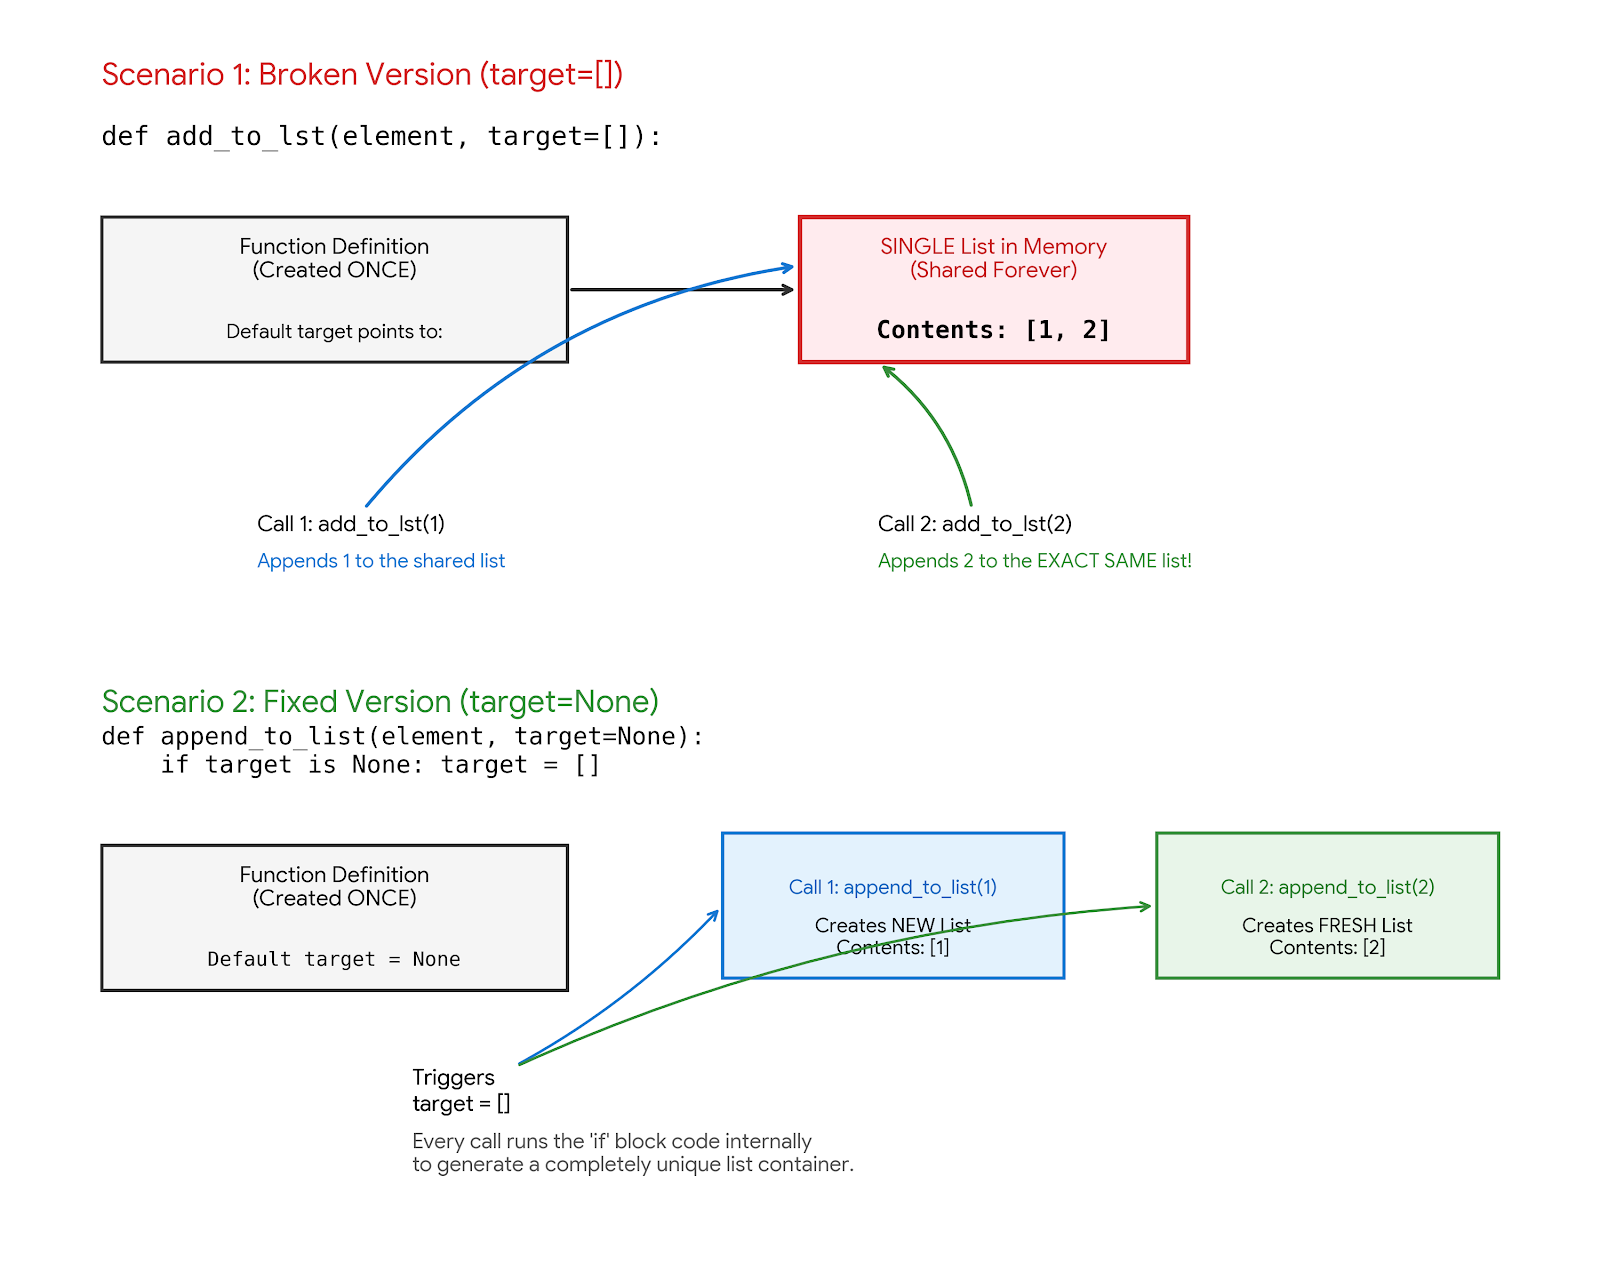

In [ ]:
"""          The target=[] version is wrong because in Python, default arguments are
             evaluated only once at function definition time, not each time the function is called.
             This means the same exact list object is reused across every call, so data accumulates
             unexpectedly across invocations—that's the classic mutable default trap. To fix it,
             we use target=None because None is immutable and safe, then inside the function we check
             if target is None: and assign target = []. This moves the list creation into the function body,
             which runs fresh every time the function is called,
             guaranteeing a brand new list for each call while still allowing us to pass in an existing list when needed."""

In [2]:
"""        == checks value equality (do these objects have the same value?)
        is checks identity equality (are these the exact same object?)"""
a = [1,2,3]
b = [1,2,3]
print(a == b)
print(a is b)

True
False


In [ ]:
"""       python my_file.py :
     1. Lexing: Your code is broken into tokens (words, symbols)
     2. Parsing: Tokens are turned into an Abstract Syntax Tree (AST)
     3. Compilation: AST is compiled into bytecode ( .pyc files)
     4. Execution: The Python Virtual Machine (PVM) executes the bytecode"""

**Namespace and Scope** ---- When Python encounters a variable name, it looks for it in this order (LEGB rule):
1. Local scope (inside the current function)
2. Enclosing scope (outer functions, if nested)
3. Global scope (module level)
4. Built-in scope ( print , len , range , etc.)

In [3]:
x = "global" # Global scope
def outer():
   x = "enclosing" # Enclosing scope
   def inner():
      x = "local" # Local scope
      print(x)  # "local"
      inner()
      print(x)  # "enclosing"
outer()
print(x) # "global"

global


In [4]:
x = "global"
def outer():
   x = "enclosing"
   def inner():
      x = "local"
      print(x)  # "local"
   inner()      # <--- CALL inner HERE (inside outer)
   print(x)     # "enclosing"
outer()
print(x)        # "global"

local
enclosing
global


In [3]:
""" Python forces you to write global because it assumes any variable you assign
to inside a function is local by default—this prevents you from accidentally destroying global variables,
 and global is your way of saying "I know what I'm doing, I really mean to change the outside one."""

total = 0

def count():
  global total
  total  += 1

count()
print(total)

1


In [3]:
"""  In Python, nonlocal is a keyword used inside nested functions to allow you to modify a
     variable defined in an outer (enclosing) function."""
def outer():
  count = 0
  def inner():
    nonlocal count
    count += 1
    return count
  return inner

my_counter = outer()

print(my_counter())
print(my_counter())
print(my_counter())

1
2
3


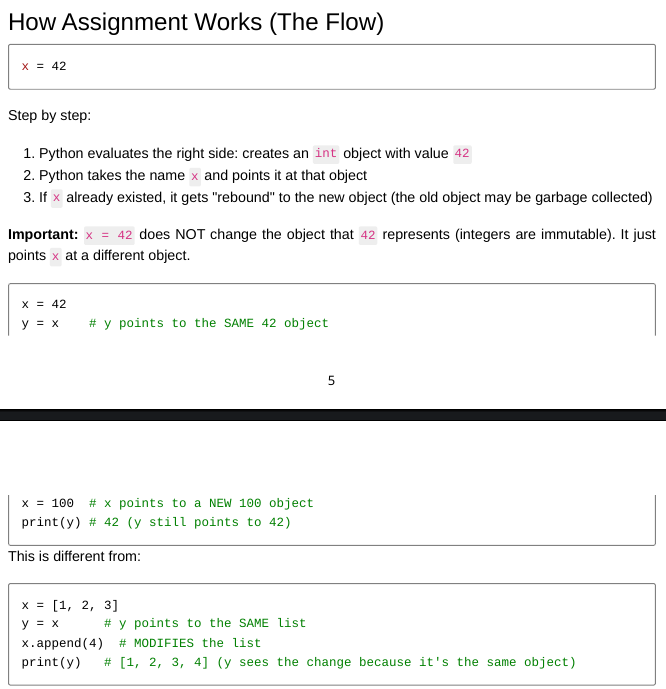

In [5]:
""" n C: for (int i = 0; i < n; i++) — this is about indexes.
In Python: for item in collection — this is about elements."""

fruits = ["apple", "banana", "cherry"]
for i in range (len(fruits)):
  print(fruits[i])

for fruit in fruits:
  print(fruit)

for i,fruit in enumerate(fruits):
  print(f"{i}: {fruit}")

apple
banana
cherry
apple
banana
cherry
0: apple
1: banana
2: cherry


In [1]:
# The Iterator Protocol
""" Everything you can loop over in Python implements the iterator protocol:
1. iter(obj) returns an iterator object
2. next(iterator) returns the next element
3. StopIteration is raised when there are no more elements"""

x = [10,20,30]
for i in x:
  print(x) # Use print(i) for printing each time

iterator = iter(x)
print(x)


while True:
  try:
    x = next(iterator)
    print(x)
  except StopIteration:
    break

[10, 20, 30]
[10, 20, 30]
[10, 20, 30]
[10, 20, 30]
10
20
30


In [2]:
""" Custom Iterator Protocol"""
class Countdown:
  def __init__(self, start):
    self.start = start

  def __iter__(self):
    return self

  def __next__(self):
    if self.start <= 0:
      raise StopIteration
    current = self.start
    self.start -= 1
    return current

for num in Countdown(5):
    print(num) # 5, 4, 3, 2, 1

5
4
3
2
1


In [3]:
# Generators
""" You use generators when you want to save your computer's memory. If you are reading a file that is 10 gigabytes large, you don't want to load the
 whole thing into your computer's RAM at once—your computer might crash. Instead, you use a generator to read one line at a time."""

" You use generators when you want to save your computer's memory. If you are reading a file that is 10 gigabytes large, you don't want to load the\n whole thing into your computer's RAM at once—your computer might crash. Instead, you use a generator to read one line at a time."

In [2]:
def countdown(start):
  while start > 0:
    yield start
    start -= 1

for num in countdown(5):
  print(num)

""" The function pauses at yield and resumes when next() is called. The local variables
are preserved between calls. This is lazy evaluation — values are produced on demand, not all at
once."""

5
4
3
2
1


In [ ]:
# memory-efficient generator
def read_long_file(filepath):
  with open(filepath) as f:
    for line in f:
      yield line.strip()

for line in read_long_file("huge_file.txt"):
    # process(line)

**Generator Expressions**

In [4]:
# List comprehension — creates the whole list in memory
squares_list = [x**2 for x in range(10)] # Uses ~8MB
# Generator expression — produces values lazily
squares_gen = (x**2 for x in range(100))
 # Uses ~120 bytes

print(squares_list)
print(squares_gen)
for sq in squares_gen:
   if sq > 100:
     break
   print(sq)

"""  Use generator expressions when you're iterating once and don't need to store the
results. Use list comprehensions when you need random access or multiple passes."""

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
<generator object <genexpr> at 0x7e50473668e0>
0
1
4
9
16
25
36
49
64
81
100


**Comprehensions**

In [7]:
# Traditional Way
squares = []
for i in range(10):
  squares.append(i**2)

# Comprehension Way
squares = [i**2 for i in range(10)]
print(squares)

# With condition
evens = [x for x in range(20) if x % 2 == 0]
print(evens)

# Nested loops
pairs = [(x, y) for x in [1, 2, 3] for y in [4, 5, 6]]
print(pairs)

# [(1, 4), (1, 5), (1, 6), (2, 4), (2, 5), ...]
# With transformation
words = ["hello", "world", "python"]
caps = [w.upper() for w in words]
print(caps)

 # ["HELLO", "WORLD", "PYTHON"]

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
[(1, 4), (1, 5), (1, 6), (2, 4), (2, 5), (2, 6), (3, 4), (3, 5), (3, 6)]
['HELLO', 'WORLD', 'PYTHON']


In [3]:
original_dict = {"a": 1, "b":2 }
inverted_One = {v:k for k,v in original_dict.items()}
print(inverted_One)

even_squares = {x: x**2 for x in range(20) if x % 2 == 0}
print(even_squares)

{1: 'a', 2: 'b'}
{0: 0, 2: 4, 4: 16, 6: 36, 8: 64, 10: 100, 12: 144, 14: 196, 16: 256, 18: 324}


In [4]:
#Functions Can Be Passed Around
def apply_twice(func, value):
   return func(func(value))

def add_one(x):
   return x + 1

print(apply_twice(add_one, 5))
 # 7 (5 -> 6 -> 7)

7


In [6]:
"""Inner Functions (Closures)
A function defined inside another function can "capture" variables from the outer function"""
def make_multiplier(factor):
   def multiply(x):
      return x * factor
 # factor is "captured" from the outer scope
   return multiply
double = make_multiplier(2)
triple = make_multiplier(3)
print(double(5))
print(triple(5))
##10
""" The inner function multiply closes over thevariablefactor .Even
after make_multiplier finishes, factor lives on inside the closure."""

10
15


In [8]:
# Args and Kwargs   Variable Arguments
def flexible_functions(a,b,*args,**kwargs):
  print(f"a={a}, b={b}")
  print(f"args={args}")
  print(f"kwargs={kwargs}")

flexible_functions(1, 2, 3, 4, 5, x=10, y=20)


def add(a, b, c):
   return a + b + c
numbers = [1, 2, 3]
print(add(*numbers))
 # 6 — unpack list into positional args


data = {"a": 10, "b": 20, "c": 30}
print(add(**data))

a=1, b=2
args=(3, 4, 5)
kwargs={'x': 10, 'y': 20}
6
60


In [9]:
# Challenge Num One
""" Write a function deep_copy(obj) that creates a true copy of a nested structure (lists of
lists, dicts of dicts, etc.) without using copy.deepcopy . Your function should handle lists, dicts, sets,
and primitive types correctly. Then explain: why does copy.copy (shallow copy) fail for nested
structures? Draw the memory diagram for original = [[1, 2], [3, 4]] and show what shallow =
copy.copy(original) actually points to."""


# Implementing a custom deep copy is a classic way to understand how Python manages memory, references, and mutability.
def deep_copy(obj):
    """
    Create a true deep copy of a nested structure without using copy.deepcopy.
    Handles: list, tuple, dict, set, and primitive types (int, float, str, bool, None).
    Other types are returned as-is (or you could raise an error).
    """
    # Primitive / immutable types: return as is
    if isinstance(obj, (int, float, str, bool, type(None))):
        return obj

    # List: copy each element recursively
    elif isinstance(obj, list):
        return [deep_copy(item) for item in obj]

    # Tuple: copy elements into a new tuple
    elif isinstance(obj, tuple):
        return tuple(deep_copy(item) for item in obj)

    # Dict: copy keys (immutable) and values recursively
    elif isinstance(obj, dict):
        return {key: deep_copy(value) for key, value in obj.items()}

    # Set: copy each element recursively (elements must be hashable)
    elif isinstance(obj, set):
        return {deep_copy(item) for item in obj}

    # For other objects (custom classes, etc.), just return the same reference
    # (or you could implement object-specific copying)
    else:
        return obj


"""
Why copy.copy (shallow copy) fails for nested structures
A shallow copy (copy.copy) creates a new container object,
but populates it with references to the same nested objects
 that the original container holds. It does not recursively copy
 inner objects. Consequently, if you modify an inner object (e.g., a nested list), that change is visible from both
the original and the shallow copy because they share the same inner object."""



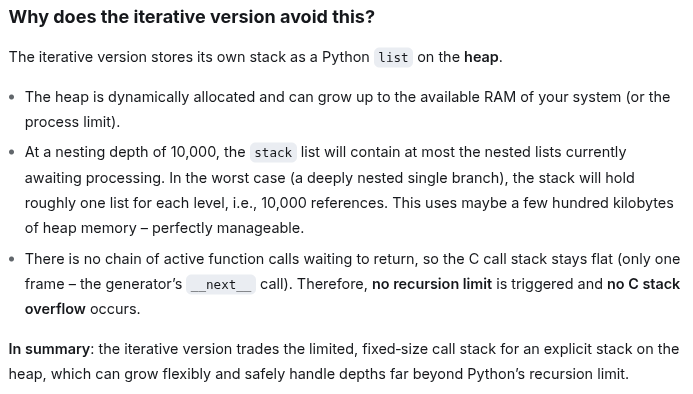

In [10]:

# Challenge Num Two
"""Write a generator flatten(nested_list) that takes a deeply nested list (e.g., [1, [2,
[3, 4]], 5, [6]] ) and yields all elements in order. Do it iteratively (no recursion), using a stack.
Then: what happens to memory usage if you used recursion for a list nested 10,000 levels deep? Why
does the iterative version avoid this?"""
def flatten(nested_list):
    """
    Yield all elements from a deeply nested list in order, using an explicit stack.
    No recursion is used.
    """
    stack = [nested_list]

    while stack:
        item = stack.pop()

        # If the item is a list, push its elements in reverse order
        # so they are popped and yielded in the original left‑to‑right order.
        if isinstance(item, list):
            stack.extend(reversed(item))
        else:
            yield item

# The stack starts with the whole input list.
# In each iteration, we pop the top element.
# If it is a list, we push its contents back in reversed order. This ensures that the first element of that list is processed next (LIFO behaviour gives us correct sequential order).
# If it is a primitive value, we yield it immediately.

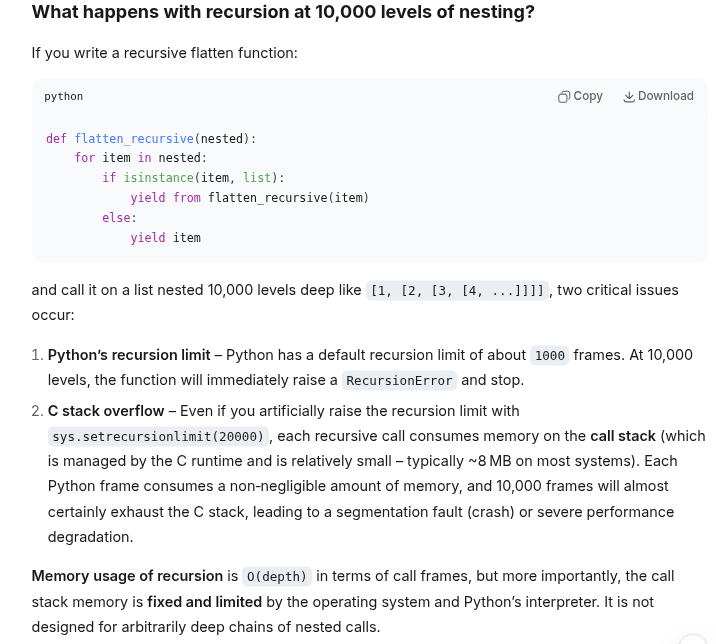